In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,roc_curve)


In [2]:
df = pd.read_csv("heart_cleveland_upload.csv")

In [3]:
X = df.drop("condition", axis=1)
y = df["condition"]

print(df.shape)
df.describe()


(297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [4]:
print(df.isnull().sum())
scaler = StandardScaler()
X = scaler.fit_transform(X)


age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]


In [6]:
knn = KNeighborsClassifier()

knn_params = {'n_neighbors': [3, 5, 7, 9]}
knn_grid = GridSearchCV(
    knn,
    knn_params,
    cv=5
)

knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_
knn_pred = best_knn.predict(X_test)
knn_prob = best_knn.predict_proba(X_test)[:, 1]


In [7]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(rf,rf_params,cv=5)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]


In [9]:
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{name}")

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("AUC ROC  :", roc_auc_score(y_true, y_prob))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))

    sns.heatmap(cm,annot=True,cmap='Blues')

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()




Logistic Regression
Accuracy : 0.7333333333333333
Precision: 0.7
Recall   : 0.75
F1 Score : 0.7241379310344828
AUC ROC  : 0.8415178571428571


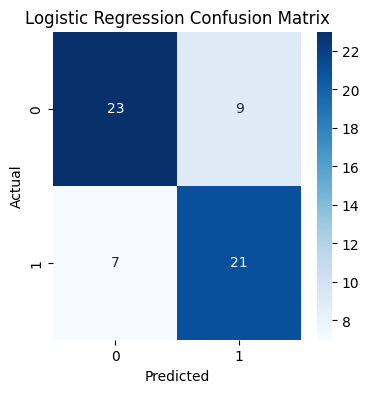

In [ ]:
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)



KNN
Accuracy : 0.7333333333333333
Precision: 0.7
Recall   : 0.75
F1 Score : 0.7241379310344828
AUC ROC  : 0.80078125


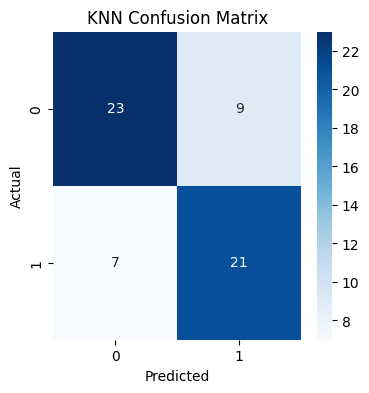

In [11]:
evaluate_model("KNN",y_test,knn_pred,knn_prob)


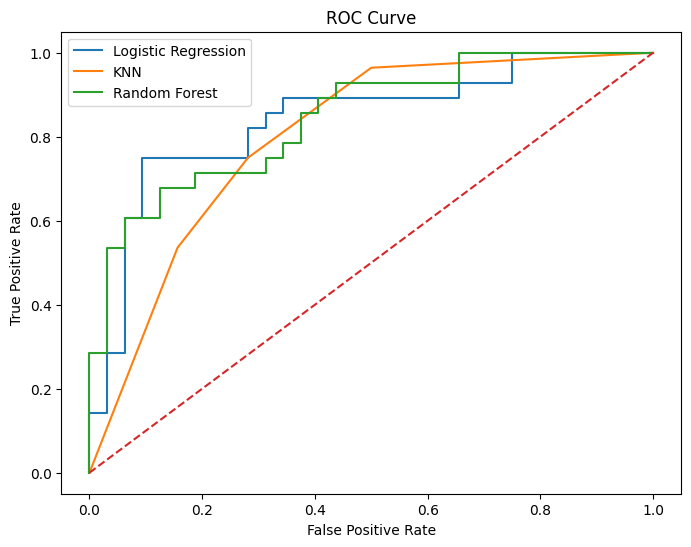

In [12]:
plt.figure(figsize=(8,6))

models = [
    ("Logistic Regression", lr_prob),
    ("KNN", knn_prob),
    ("Random Forest", rf_prob)
]

for name, prob in models:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()



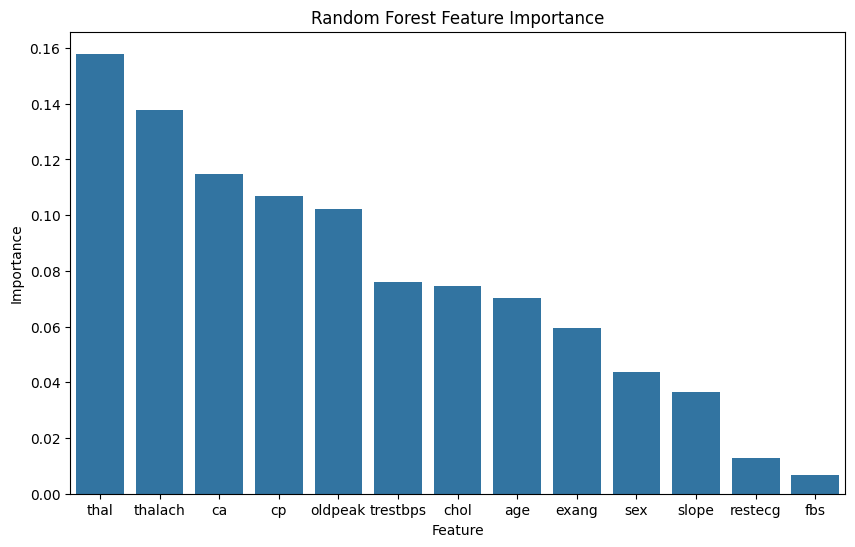

In [13]:
importance = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': df.drop("condition", axis=1).columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
plt.figure(figsize=(10,6))

sns.barplot(
    x='Feature',
    y='Importance',
    data=feature_importance
)
plt.title("Random Forest Feature Importance")
plt.show()

In [27]:
print("\nEnter Patient Details:")

age = float(input("Age: "))
sex = float(input("Gender (0,1): "))
cp = float(input("Chest Pain Type (0-3): "))
chol = float(input("Cholesterol: "))
thalach = float(input("Maximum Heart Rate: "))
exang = float(input("Exercise Induced Angina (1=yes, 0=no): "))
oldpeak = float(input("Oldpeak: "))
ca = float(input("Number of Major Vessels (0-4): "))
thal = float(input("Thal (0-3): "))

trestbps = 120
fbs = 0
restecg = 1
slope = 1

user_data = pd.DataFrame([[
    age,
    sex,
    cp,
    trestbps,
    chol,
    fbs,
    restecg,
    thalach,
    exang,
    oldpeak,
    slope,
    ca,
    thal
]], columns=df.drop("condition", axis=1).columns)

user_data = scaler.transform(user_data)
prediction = best_rf.predict(user_data)

if prediction[0] == 1:
    print("\nPrediction: Heart Disease Detected")
else:
    print("\nPrediction: No Heart Disease")


Enter Patient Details:

Prediction: Heart Disease Detected


f:\house-price-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
